In [1]:
import os
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.io import fits
from astropy.convolution import convolve
from astropy.modeling.models import Sersic2D
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
import astropy.units as u
from astropy.constants import c
from reproject import reproject_interp
from scipy.optimize import minimize, least_squares
from scipy.signal import fftconvolve, convolve2d
import dynesty
import dynesty.pool as dypool
from dynesty import plotting as dyplot
import dynesty.utils as dyutil
import pickle
import corner
from cmcrameri import cm
from multiprocessing import Pool
import importlib
import warnings
warnings.simplefilter('ignore', DeprecationWarning)
%matplotlib inline
# seed the random number generator
rstate = np.random.default_rng(111)

from glint.beam import cleanbeam_from_header
import glint.lensing as ls
from glint.context import ImageContext
from glint.forward import forward_model_3D_image
from glint.inference import run_emcee
from glint.plotstyle import set_my_plot_style
from params_kinematics import param_names, param_table

In [2]:
set_my_plot_style()

In [3]:
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

## Data

Beam size: 0.21, 0.12


Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


hst peak: 8.0, 17.0 pix, corresponding to 0.160, 0.340 arcsec from the center
hst centroid: 4.7, 3.5 pix, corresponding to 0.093, 0.070 arcsec from the center
hst gaussian fit: 10.8, 14.5 pix, corresponding to 0.217, 0.290 arcsec from the center


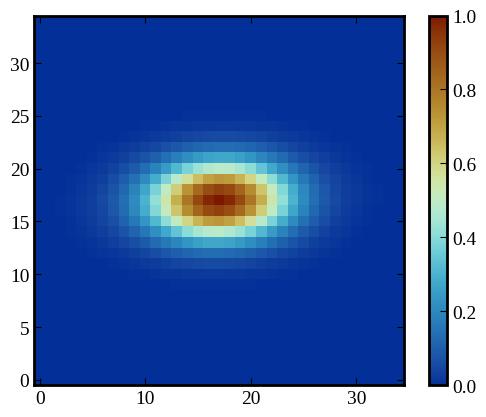

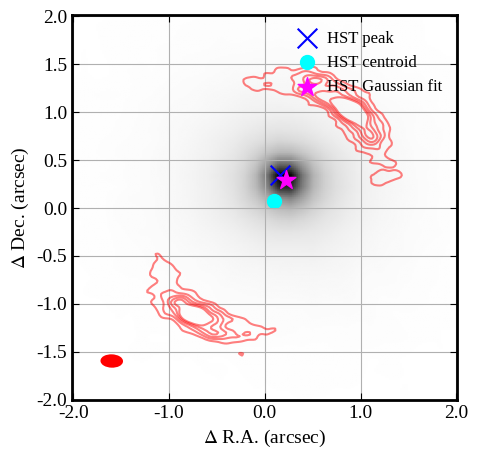

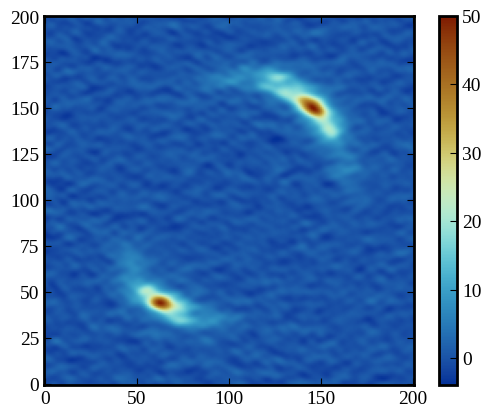

In [4]:
# image data
data_dir = Path("./data").resolve()
data_dir.exists()

obsfits   = str(data_dir / "B6_concat_CII_dv50km_rob-0.5_clean.image.pbcor.cutout.-250+300km.fits")
noisefits = str(data_dir / "B6_concat_CII_dv50km_rob-0.5_clean.noise.pbcor.cutout.-250+300km.fits")

obsdata, obsheader = fits.getdata(obsfits, header=True)
noisedata = fits.getdata(noisefits)
noisedata_inv = 1/noisedata
BMAJ, BMIN, BPA, CDELT = obsheader['BMAJ'], obsheader['BMIN'], obsheader['BPA'], obsheader['CDELT2']
print(f"Beam size: {BMAJ*3600:.2f}, {BMIN*3600:.2f}")
beam = cleanbeam_from_header(35, obsheader)
plt.imshow(beam, origin="lower", cmap=cm.roma_r)
plt.colorbar()


#### Continuum data for overlay ####
contfits   = str(data_dir / "B6_concat_cont_rob-0.5_clean.image.pbcor.cutout.fits")
contnoisefits = str(data_dir / "B6_concat_cont_rob-0.5_clean.noise.pbcor.cutout.fits")

contdata, contheader = fits.getdata(contfits, header=True)
contnoisedata = fits.getdata(contnoisefits)
####

# あとは同じ
hst_fits = str(data_dir / "hst_skycell-p1356x14y05_wfc3_ir_f125w_coarse-all_drz.fits")
hst_data, hst_header = fits.getdata(hst_fits, header=True)
hst_wcs = WCS(hst_header)

# reproject to ALMA
hst_on_alma, footprint = reproject_interp((hst_data, hst_wcs), WCS(contheader, naxis=2), shape_out=contdata.shape)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(hst_on_alma, origin='lower', cmap='gray_r')
ax.contour(contdata/contnoisedata, levels=[4,8,12,16,20], colors='red', alpha=0.5)

# 画像の中心
ny, nx = contdata.shape
x0 = (nx - 1) / 2
y0 = (ny - 1) / 2
pixscale_as = abs(obsheader['CDELT2'] * 3600) # arcsec/pix
def format_func_x(x_pix, _):
    return f"{(x_pix - x0) * pixscale_as:.1f}"
def format_func_y(y_pix, _):
    return f"{(y_pix - y0) * pixscale_as:.1f}"
from matplotlib.ticker import FuncFormatter
ax.xaxis.set_major_formatter(FuncFormatter(format_func_x))
ax.yaxis.set_major_formatter(FuncFormatter(format_func_y))

# psfサイズをimage planeの左下に楕円として表示
xy_beam = (0.10*nx, 0.10*ny)
ellipse = Ellipse(xy=xy_beam, width=BMAJ/CDELT, height=BMIN/CDELT, angle=BPA+90, edgecolor='red', facecolor='red', lw=1.5)
ax.add_patch(ellipse)
ax.grid()

# HST peak
hst_peak = np.unravel_index(np.nanargmax(hst_on_alma), hst_on_alma.shape)
ax.scatter(hst_peak[1], hst_peak[0], marker='x', color='blue', s=200, label='HST peak')

# HST centroid
from photutils.centroids import centroid_com
y_com, x_com = centroid_com(hst_on_alma)
ax.scatter(x_com, y_com, marker='o', color='cyan', s=100, label='HST centroid')

# HST gaussian fit
def gauss2d(p, x, y):
    A, x0, y0, sx, sy, rho, c = p
    # 相関rho入り楕円ガウス：必要なければ rho=0 に固定
    X = (x - x0); Y = (y - y0)
    z = (X/sx)**2 + (Y/sy)**2 - 2*rho*X*Y/(sx*sy)
    return A*np.exp(-0.5/(1-rho**2) * z) + c
ny, nx = hst_on_alma.shape
yy, xx = np.indices((ny, nx))
p0 = [hst_on_alma.max(), x_com, y_com, 3.0, 3.0, 0.0, 0.0]
use = np.isfinite(hst_on_alma)
def resid(p): return (gauss2d(p, xx[use], yy[use]) - hst_on_alma[use])
res = least_squares(resid, p0, bounds=([0,0,0,0.5,0.5,-0.5,-np.inf],
                                       [np.inf,nx,ny,50,50,0.5,np.inf]))
A,x0_g,y0_g,sx,sy,rho,c = res.x
ax.scatter(x0_g, y0_g, marker='*', color='magenta', s=200, label='HST Gaussian fit')

ax.set_xlabel(r"$\Delta$ R.A. (arcsec)", fontsize=14)
ax.set_ylabel(r"$\Delta$ Dec. (arcsec)", fontsize=14)
ax.legend(fontsize=12)
print(f"hst peak: {hst_peak[1]-x0:.1f}, {hst_peak[0]-y0:.1f} pix, corresponding to {((hst_peak[1]-x0)*pixscale_as):.3f}, {((hst_peak[0]-y0)*pixscale_as):.3f} arcsec from the center")
print(f"hst centroid: {x_com-x0:.1f}, {y_com-y0:.1f} pix, corresponding to {((x_com-x0)*pixscale_as):.3f}, {((y_com-y0)*pixscale_as):.3f} arcsec from the center")
print(f"hst gaussian fit: {x0_g-x0:.1f}, {y0_g-y0:.1f} pix, corresponding to {((x0_g-x0)*pixscale_as):.3f}, {((y0_g-y0)*pixscale_as):.3f} arcsec from the center")

x0_l = (x0_g-x0)*pixscale_as
y0_l = (y0_g-y0)*pixscale_as


# mask
# obsdata[maskdata==0] = np.nan
# noisedata_inv[maskdata==0] = np.nan

fig, ax = plt.subplots()
im = ax.imshow(contdata/contnoisedata, origin="lower", cmap=cm.roma_r)
# ax.contour(maskdata)
fig.colorbar(im, ax=ax)

In [5]:
from astropy.constants import c
# 周波数方向の情報

# model作成時は速度で指定
vchan_kms = np.arange(-300, 351, 50)

# [CII]158を想定
REST_FREQ_CII = 1900.5369 * u.GHz
z = 6.024
OBS_FREQ_CII = REST_FREQ_CII / (1 + z)

# Transform velocity channels to frequency channels
# V/c = -dnu/f --> dnu = - (V/c) * f --> nu = f + dnu = f * (1 - V/c)
fchan_GHz = (OBS_FREQ_CII * (1 - vchan_kms / c.to(u.km / u.s).value)).to(u.GHz).value
print(fchan_GHz)

f0 = fchan_GHz[0]
df = np.mean(np.diff(fchan_GHz))
print(f"f0: {f0} GHz, df: {df} GHz, RESTFRQ: {OBS_FREQ_CII.to(u.GHz).value} GHz")

[270.84834177 270.80321429 270.75808681 270.71295933 270.66783184
 270.62270436 270.57757688 270.5324494  270.48732191 270.44219443
 270.39706695 270.35193947 270.30681199 270.2616845 ]
f0: 270.84834177310904 GHz, df: -0.045127482306322866 GHz, RESTFRQ: 270.5775768792711 GHz


## simobserveしたものを読み出す

In [6]:
######################
# data
######################
sim_lensed_cube, h = fits.getdata('./sim_imaging/casa_dirty.image.fits', header=True)
nchan = len(sim_lensed_cube)
pixsize_img = round(abs(h['CDELT2']) * 3600, 2)
print(f"Pixel size: {pixsize_img:.2f} arcsec")

from astropy.stats import sigma_clipped_stats, mad_std
rms1 = mad_std(sim_lensed_cube[0], ignore_nan=True)
rms2 = mad_std(sim_lensed_cube[-1], ignore_nan=True)
rms = (rms1 + rms2) / 2
print(f"Estimated RMS from the first and last channels: {rms:.4e}")


Pixel size: 0.02 arcsec
Estimated RMS from the first and last channels: 1.5733e-03


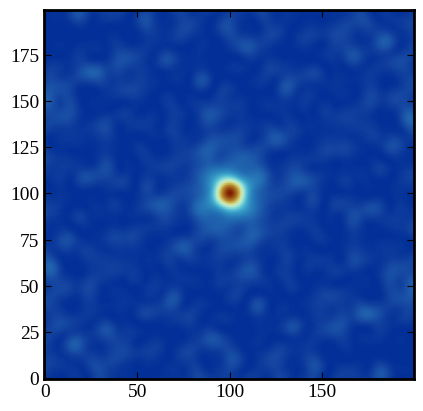

Peak pixel: (np.int64(100), np.int64(100)), value: 1.0000e+00


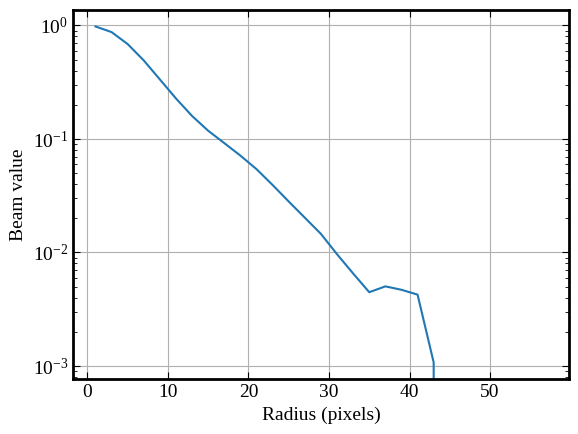

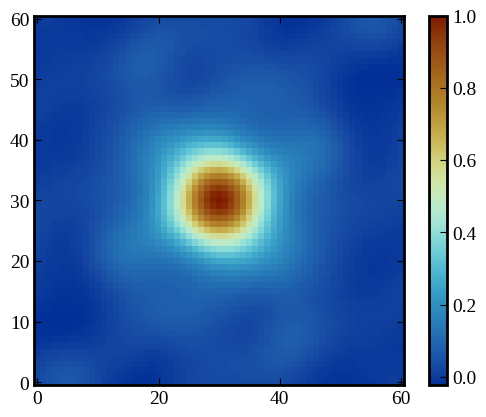

Peak pixel: (np.int64(30), np.int64(30)), value: 1.0000e+00


(14, 61, 61)

In [7]:
######################
# psf
######################
beam = fits.getdata('./sim_imaging/casa_dirty.psf.fits')
plt.imshow(beam[0], origin="lower", cmap=cm.roma_r)
plt.show()
# peak pixel
peak_pix = np.unravel_index(np.nanargmax(beam[0]), beam[0].shape)
print(f"Peak pixel: {peak_pix}, value: {beam[0][peak_pix]:.4e}")

# radial profile
y, x = np.indices(beam[0].shape)
y_center, x_center = peak_pix
r = np.sqrt((x - x_center)**2 + (y - y_center)**2)
r_flat = r.flatten()
beam_flat = beam[0].flatten()
# Sort by radius
sorted_indices = np.argsort(r_flat)
r_sorted = r_flat[sorted_indices]
beam_sorted = beam_flat[sorted_indices]
# Bin the data
r_bins = np.arange(0, 60, 2)  # pixel
r_bin_centers = 0.5 * (r_bins[:-1] + r_bins[1:])
beam_radial_profile = np.zeros(len(r_bin_centers))
for i in range(len(r_bin_centers)):
    in_bin = (r_sorted >= r_bins[i]) & (r_sorted < r_bins[i+1])
    if np.sum(in_bin) > 0:
        beam_radial_profile[i] = np.nanmean(beam_sorted[in_bin])    
plt.plot(r_bin_centers, beam_radial_profile)
plt.xlabel("Radius (pixels)")
plt.ylabel("Beam value")
plt.yscale("log")
plt.grid()
plt.show()

# cutout each channel around the same peak (odd size to have a central pixel)
cutout_size = 61  # pixels
half_size = cutout_size // 2
beam_cutout = beam[:, peak_pix[0]-half_size:peak_pix[0]+half_size+1, peak_pix[1]-half_size:peak_pix[1]+half_size+1]

plt.imshow(beam_cutout[0], origin="lower", cmap=cm.roma_r)
plt.colorbar()
plt.show()

peak_pix = np.unravel_index(np.nanargmax(beam_cutout[0]), beam_cutout[0].shape)
print(f"Peak pixel: {peak_pix}, value: {beam_cutout[0][peak_pix]:.4e}")
beam_cutout.shape

In [8]:
# mask definition
maskdata = np.zeros(sim_lensed_cube[0].shape).astype(bool)

# RMS基準にマスクを定義する場合
# thresh = 2
# maskdata[obsdata*noisedata_inv > thresh] = True

# 固定マスクを使う場合
# 円環マスク
r_inner = 0.4 # arcsec
r_outer = 2.0 # arcsec
y, x = np.indices(sim_lensed_cube[0].shape)
x_center = sim_lensed_cube[0].shape[1] / 2
y_center = sim_lensed_cube[0].shape[0] / 2
r = np.sqrt((x - x_center)**2 + (y - y_center)**2) * pixsize_img
maskdata[(r >= r_inner) & (r <= r_outer)] = True


Npix = np.nansum(maskdata)
print(f"Number of pixels in the mask: {Npix}")


Number of pixels in the mask: 30170


In [9]:
# source plane grid
ny_src, nx_src = 200, 200
pixsize_src = 0.005 # arcsec
x0_src, y0_src = 0.0, 0.0
xx_src, yy_src = ls.make_grid_arcsec(nx=nx_src, ny=ny_src, pixscale_arcsec=pixsize_src, x0_arcsec=x0_src, y0_arcsec=y0_src)

# image plane grid
nchan, ny_img, nx_img = sim_lensed_cube.shape
print(f"Number of channels: {nchan}")
print(f"Number of pixels in image plane: {nx_img} x {ny_img}")
print(f"Pixel scale in image plane: {pixsize_img} arcsec/pixel")
x0_img, y0_img = 0.0, 0.0
xx_img, yy_img = ls.make_grid_arcsec(nx=nx_img, ny=ny_img, pixscale_arcsec=pixsize_img, x0_arcsec=x0_img, y0_arcsec=y0_img)

radius = np.arange(0, 0.8+1e-6, 0.01) # 0含める

spec_res_sgm_kms = 50 / (2 * np.sqrt(2 * np.log(2)))  # 50 km/s channel width -> sigma


Number of channels: 14
Number of pixels in image plane: 200 x 200
Pixel scale in image plane: 0.02 arcsec/pixel


## Intrinsic cube model

In [10]:
# inclination from mom-0 fit

savename = f"./mcmc_chain_CII_mom0_image.npz"
npzfile = np.load(savename, allow_pickle=True)

chain = npzfile["chain"]              # shape: (nsteps, nwalkers, ndim)
logprob = npzfile["logprob"]          # shape: (nsteps, nwalkers)
param_names_mom0 = list(npzfile["param_names"])

# 最も logprob が大きい点を best-fit とする
idx = np.unravel_index(np.argmax(logprob), logprob.shape)
best_theta = chain[idx[0], idx[1], :]

for name, best in zip(param_names_mom0, best_theta):
    print(f"{name:12s}  best={best:10.4f}")

x_s_from_mom0_fit = best_theta[0]
y_s_from_mom0_fit = best_theta[1]
ellip = best_theta[3]
axis_ratio = 1 - ellip
print(f"Best-fit axis ratio: {axis_ratio:.3f}")
inc_deg_from_mom0_fit = np.degrees(np.arccos(axis_ratio))
print(f"Best-fit inclination: {inc_deg_from_mom0_fit:.2f} deg")

x_s           best=    0.0348
y_s           best=    0.0291
F_0           best=    9.4547
ellip         best=    0.1517
pa_deg        best=  100.4099
r_eff         best=    0.2009
n             best=    0.5000
b             best=    1.2845
q_l           best=    0.9558
pa_l          best=    2.3784
log_gamma     best=   -1.2749
pa_gamma      best=    1.0912
Best-fit axis ratio: 0.848
Best-fit inclination: 31.97 deg


In [11]:
ctx = ImageContext(
    xx_img = xx_img,
    yy_img = yy_img,
    xx_src = xx_src,
    yy_src = yy_src,
    pixsize_img = pixsize_img,
    pixsize_src = pixsize_src,
    x0_src = x0_src,
    y0_src = y0_src,
    x0_l = x0_l,
    y0_l = y0_l,
    vchan_kms = vchan_kms,
    spec_res_sgm_kms = spec_res_sgm_kms,
    radius_arcsec = radius,
    beam = beam_cutout,
    x_s = x_s_from_mom0_fit,
    y_s = y_s_from_mom0_fit,
    inc_deg = inc_deg_from_mom0_fit
)

In [12]:
mock_x_s, mock_y_s = 0.034, 0.029
mock_F_0 = 5
mock_inc_deg = 30.0
mock_pa_deg = 45.0
mock_r_scale = 0.1 # arcsec
mock_v_c = 350.0 # km/s
mock_r_turn = 0.1 # arcsec
mock_beta_curve = 0.8
mock_gamma_curve = 2.5
mock_sigma_0 = 100.0 # km/s
mock_r_sigma = 0.8 # arcsec
mock_vsys_kms = 20.0 # km/s
mock_x_l, mock_y_l = x0_l, y0_l
mock_b = 1.2 # arcsec
mock_q_l = 1
mock_pa_l = np.pi/2 # rad
mock_log_gamma = -2
mock_pa_gamma = np.pi/4 # rad

mock_params = [
    # mock_x_s, mock_y_s, mock_F_0, mock_inc_deg, mock_pa_deg, mock_r_scale,
    mock_F_0, mock_pa_deg, mock_r_scale,
    mock_v_c, mock_r_turn, mock_beta_curve, mock_gamma_curve, mock_sigma_0, mock_r_sigma, mock_vsys_kms,
    mock_b, mock_log_gamma, mock_pa_gamma
    # mock_x_l, mock_y_l, mock_b, mock_q_l, mock_pa_l, mock_log_gamma, mock_pa_gamma
]


mock_source, mock_lensed_cube, mock_lensed_cube_conv = forward_model_3D_image(mock_params, ctx)

# mock rms
rms = np.max(mock_lensed_cube_conv) / 10.0
mock_lensed_cube_conv += rstate.normal(loc=0.0, scale=rms, size=mock_lensed_cube_conv.shape)


# minimum header
header = WCS(obsheader).to_header()
header["BUNIT"] = "Jy/pix"

# frequency axis info
header['CRPIX3'] = 1
header['CRVAL3'] = f0 * 1e9  # Hz
header['CDELT3'] = df * 1e9  # Hz
header['CUNIT3'] = 'Hz'
header['RESTFRQ'] = OBS_FREQ_CII.to(u.Hz).value

# save mock data
# fits.writeto("mock_lensed_cube.fits", mock_lensed_cube, header=header, overwrite=True)

Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


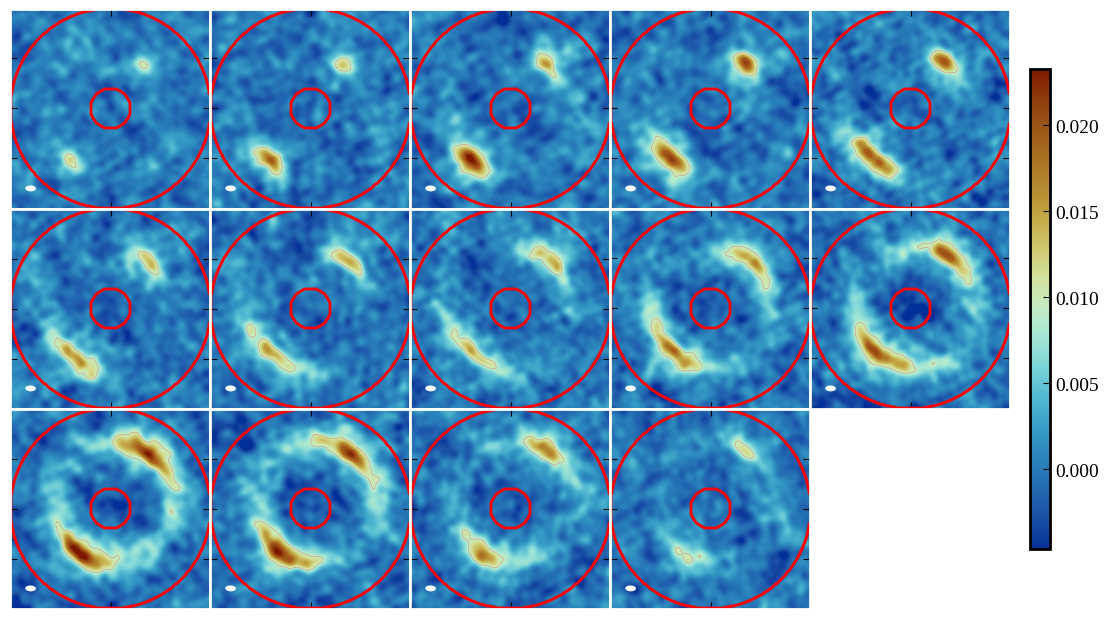

In [ ]:
# plot channel maps
n_cols = 5
n_chan = sim_lensed_cube.shape[0]
n_rows = int(np.ceil(n_chan / n_cols))

start = 0

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(2*n_cols, 2*n_rows))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0.0, hspace=0.0)
for i in range(n_rows * n_cols):
    row = i // n_cols
    col = i % n_cols
    ax = axes[row, col]
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.spines['bottom'].set_color("white")
    ax.spines['top'].set_color("white")
    ax.spines['right'].set_color("white")
    ax.spines['left'].set_color("white")
    if i < n_chan:
        ax.imshow(sim_lensed_cube[start+i], cmap=cm.roma_r, origin="lower", vmin=-2*rms, vmax=10*rms)
        ax.contour(sim_lensed_cube[start+i]/rms, levels=[4, 8, 12, 16, 32], colors='red', alpha=0.7, linewidths=0.2)
        
        # ax.annotate(f"{int(vel_start+dv*i)}km/s", xy=(0.25, 0.87), xytext=(0, 0), color='white', xycoords='axes fraction', textcoords='offset points',weight='bold', ha='center', va='baseline', fontsize=25)
        xy_beam = (0.10*nx, 0.10*ny)
        ellipse = Ellipse(xy=xy_beam, width=BMAJ/CDELT, height=BMIN/CDELT, angle=BPA+90., edgecolor='none', fc='white', lw=0.5)  # must be define any time
        ax.add_patch(ellipse)
        ax.contour(maskdata, levels=[0.5], colors='red', linewidths=2)
    
    # if i==0:
    #     size = 1/pix
    #     fontprops = fm.FontProperties(size=40)
    #     scalebar = AnchoredSizeBar(ax.transData,
    #                             size, r'1$^{\prime\prime}$', 'lower right',
    #                             pad=0.3,
    #                             sep=5,
    #                             color='white',
    #                             frameon=False,
    #                             size_vertical=2,
    #                             fontproperties=fontprops)
    #     ax.add_artist(scalebar)
    
    if i >= n_chan:
        ax.axis('off')

# 全体のカラーバー
cbar_ax = fig.add_axes([1.02, 0.1, 0.02, 0.8])  # [left, bottom, width, height]
norm = plt.Normalize(vmin=-2*rms, vmax=10*rms)
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cm.roma_r), cax=cbar_ax)

In [ ]:
# plot channel maps
n_cols = 5
n_chan = mock_lensed_cube_conv.shape[0]
n_rows = int(np.ceil(n_chan / n_cols))

start = 0

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(2*n_cols, 2*n_rows))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0.0, hspace=0.0)
for i in range(n_rows * n_cols):
    row = i // n_cols
    col = i % n_cols
    ax = axes[row, col]
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.spines['bottom'].set_color("white")
    ax.spines['top'].set_color("white")
    ax.spines['right'].set_color("white")
    ax.spines['left'].set_color("white")
    if i < n_chan:
        ax.imshow(mock_lensed_cube[start+i], cmap=cm.roma_r, origin="lower", vmin=0, vmax=1e-3)
        # ax.contour(mock_lensed_cube[start+i]/rms, levels=[4, 8, 12, 16, 32], colors='red', alpha=0.7, linewidths=0.2)
        
    if i >= n_chan:
        ax.axis('off')

# 全体のカラーバー
cbar_ax = fig.add_axes([1.02, 0.1, 0.02, 0.8])  # [left, bottom, width, height]
norm = plt.Normalize(vmin=0, vmax=1e-3)
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cm.roma_r), cax=cbar_ax)

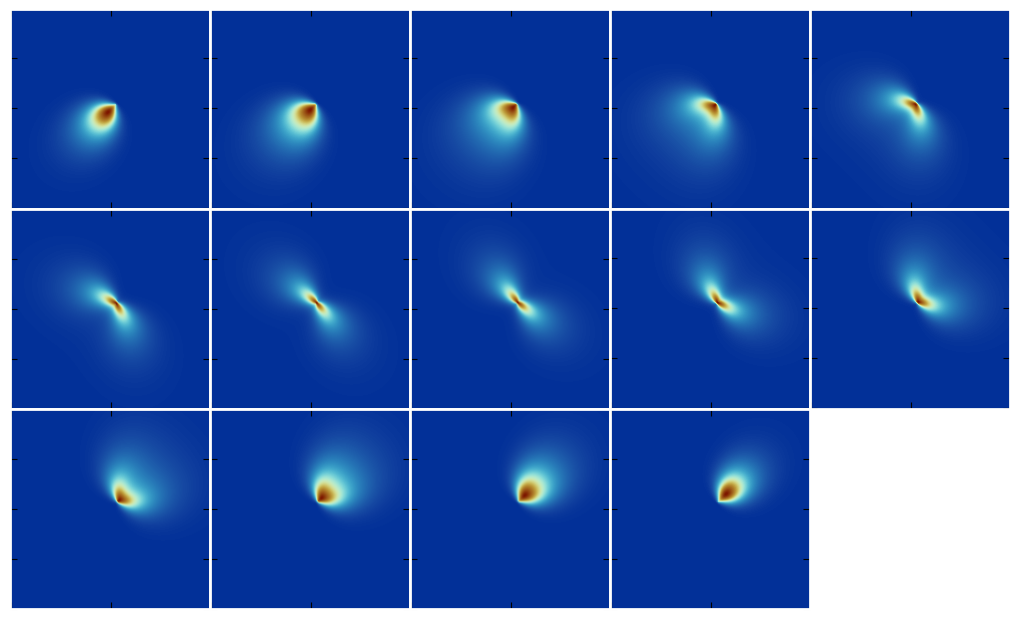

In [ ]:
# plot channel maps
n_cols = 5
n_chan = mock_lensed_cube_conv.shape[0]
n_rows = int(np.ceil(n_chan / n_cols))

start = 0

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(2*n_cols, 2*n_rows))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0.0, hspace=0.0)
for i in range(n_rows * n_cols):
    row = i // n_cols
    col = i % n_cols
    ax = axes[row, col]
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.spines['bottom'].set_color("white")
    ax.spines['top'].set_color("white")
    ax.spines['right'].set_color("white")
    ax.spines['left'].set_color("white")
    if i < n_chan:
        ax.imshow(mock_source[start+i], cmap=cm.roma_r, origin="lower")#, vmin=-0.5*rms, vmax=10*rms)
        # ax.contour(mock_lensed_cube_conv[start+i], level*rms, colors=linecolor, linestyles=linestyles, linewidths=linewidths)
        
        # ax.annotate(f"{int(vel_start+dv*i)}km/s", xy=(0.25, 0.87), xytext=(0, 0), color='white', xycoords='axes fraction', textcoords='offset points',weight='bold', ha='center', va='baseline', fontsize=25)
        # ellipse = Ellipse(xy=(0,0), width=BMAJ, height=BMIN, angle=BPA+90.,edgecolor='none', fc='white', lw=0.5)  # must be define any time
        # draw_ellipse(ax, ellipse)
    
    # if i==0:
    #     size = 1/pix
    #     fontprops = fm.FontProperties(size=40)
    #     scalebar = AnchoredSizeBar(ax.transData,
    #                             size, r'1$^{\prime\prime}$', 'lower right',
    #                             pad=0.3,
    #                             sep=5,
    #                             color='white',
    #                             frameon=False,
    #                             size_vertical=2,
    #                             fontproperties=fontprops)
    #     ax.add_artist(scalebar)
    
    if i >= n_chan:
        ax.axis('off')

In [ ]:
x0 = param_table[:,0]
lb = param_table[:,1]
ub = param_table[:,2]
ndim = len(lb)

## Fitting

In [ ]:
# from glint.inference import run_least_squares

# dof = np.sum(maskdata) * obsdata.shape[0]  # number of pixels in the mask * number of channels
# dof_inv = 1/dof

# # def residual(theta):
# #     model = forward_model_3D_image(theta, ctx)[2]
# #     diff = (obsdata - model) * noisedata_inv
# #     chi2 = np.sum(diff[:, maskdata]**2) * dof_inv
# #     return chi2

# mask_flat = maskdata.ravel()
# def residual_vec(theta):
#     model = forward_model_3D_image(theta, ctx)[2]          # (nchan, ny, nx)
#     r = (mock_lensed_cube - model) * noisedata_inv                  # 同shape
#     r = r.reshape(r.shape[0], -1)[:, mask_flat]            # (nchan, Nmask)
#     return r.ravel()                                       # (nchan*Nmask,)


# result = run_least_squares(residual_vec, x0, lb, ub)

In [ ]:
# best_fit = result.x

# print("Best-fit parameters:")
# for name, val in zip(param_names, best_fit):
#     print(f"{name}: {val:.4f}")

In [ ]:
# # rotation curve
# from glint.source import Vrot_Courteau1997

# radius_rc = np.arange(0, 0.8+1e-6, 0.01) # 0含める
# vrot_bestfit = Vrot_Courteau1997(r=radius_rc, v_c=best_fit[3], r_turn=best_fit[4], gamma=best_fit[6], beta=best_fit[5])
 

# fig, ax = plt.subplots(figsize=(5,3))
# ax.plot(radius_rc, Vrot_Courteau1997(r=radius_rc, v_c=mock_v_c, r_turn=mock_r_turn, gamma=mock_gamma_curve, beta=mock_beta_curve), color='tab:orange', label='True rotation curve')
# ax.plot(radius_rc, vrot_bestfit, color='blue', label='Best-fit rotation curve')
# ax.set_xlabel('Radius  /arcsec', fontsize=14)
# ax.set_ylabel(r'Rotation Velocity  /km s$^{-1}$', fontsize=14)
# ax.legend(fontsize=12)
# # ax.set_ylim(300, 500)
# # fig.savefig(f"./figure/rotation_curve_fit_G09_{dv}_lens_fix.pdf", dpi=200, bbox_inches="tight")
# # print(f"Saved to ./figure/rotation_curve_fit_G09_{dv}_lens_fix.pdf")
# plt.show()

In [ ]:
# # model with best-fit parameters
# best_source, best_lensed_cube, best_lensed_cube_conv = forward_model_3D_image(best_fit, ctx)

# # Plot cube for each channel
# # Some settings for plotting
# vmax = np.nanmax(mock_lensed_cube_conv) * 0.9
# width = 2
# titles = ["Observation", "Model", "Residual", "Source"]


# fig, axes = plt.subplots(nchan, ncols=4, figsize=(width*4, width*nchan))
# fig.subplots_adjust(wspace=0., hspace=0.0)
# for i in range(nchan):
#     im0 = axes[i, 0].imshow(mock_lensed_cube_conv[i], cmap=cm.roma_r, origin="lower", vmin=0, vmax=vmax)
#     axes[i, 0].contour(mock_lensed_cube_conv[i]/noisedata[i], levels=[8,16,32], colors='black', linewidths=1.0)
#     im1 = axes[i, 1].imshow(best_lensed_cube_conv[i], cmap=cm.roma_r, origin="lower", vmin=0, vmax=vmax)
#     im2 = axes[i, 2].imshow((mock_lensed_cube_conv[i] - best_lensed_cube_conv[i]), cmap=cm.roma_r, origin="lower", vmin=0, vmax=vmax)
#     # im2 = axes[i, 2].imshow((obsdata[i] - best_lensed_cube_conv[i]) / noisedata[i], cmap=cm.roma_r, origin="lower", vmin=-3, vmax=3)
#     axes[i, 2].contour((mock_lensed_cube_conv[i] - best_lensed_cube_conv[i]) / noisedata[i], levels=[-5,-4,-3,3,4,5], colors='black', linewidths=0.5)
#     im3 = axes[i, 3].imshow(best_source[i], cmap=cm.roma_r, origin="lower", vmin=0, vmax=np.nanmax(best_source))

#     if i==0:
#         for j in range(4):
#             axes[i, j].set_title(titles[j], fontsize=14, pad=-2)
#     for j in range(4):
#         # divider = make_axes_locatable(axes[i,j])
#         # cax = divider.append_axes("right", size="5%", pad=0.)
#         # fig.colorbar([im0, im1, im2, im3][j], cax=cax)
#         axes[i, j].set_xticklabels([])
#         axes[i, j].set_yticklabels([])

    
# # fig.savefig("./figure/channel_maps_fit_G09_lens_fix.pdf", dpi=200, bbox_inches="tight")
# # print("Saved to ./figure/channel_maps_fit_G09_lens_fix.pdf")
# # plt.tight_layout()

## 時間計測

In [ ]:
# from __future__ import annotations
# import numpy as np
# from typing import Tuple
# from scipy.signal import fftconvolve
# from scipy.fft import fftn, ifftn
# from glint.context import ImageContext, UVContext
# from glint import lensing as ls
# from glint.source import make_rotating_disk_cube, Vrot_Courteau1997, sersic2d
# import time
# from contextlib import contextmanager, nullcontext

# @contextmanager
# def timer(name):
#     t0 = time.perf_counter()
#     yield
#     t1 = time.perf_counter()
#     print(f"{name:25s}: {(t1-t0)*1e3:8.2f} ms")



# def forward_model_3D_image(params: np.ndarray, ctx: ImageContext) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    
#     t_total0 = time.perf_counter()
    
#     p = np.asarray(params, dtype=float)

#     # x_s, y_s, F_0, inc_deg, pa_deg, r_scale, v_c, r_turn, gamma_curve, sigma_0, r_sigma, vsys_kms, \
#         # x_l, y_l, b, q_l, pa_l, log_gamma, pa_gamma = params
#     # x_s, y_s, F_0, inc_deg, pa_deg, r_scale, v_c, r_turn, gamma_curve, sigma_0, r_sigma, vsys_kms, \
#     # x_s, y_s, F_0, inc_deg, pa_deg, r_scale, v_c, r_turn, beta_curve, gamma_curve, sigma_0, r_sigma, vsys_kms, \
#     #     b, q_l, pa_l, log_gamma, pa_gamma = p
#     # x_s, y_s inc_deg --> fix
#     # F_0, pa_deg, r_scale, v_c, r_turn, beta_curve, gamma_curve, sigma_0, r_sigma, vsys_kms, \
#     #     b, q_l, pa_l, log_gamma, pa_gamma = p

#     # x_s, y_s inc_deg --> fix
#     F_0, pa_deg, r_scale, v_c, r_turn, beta_curve, gamma_curve, sigma_0, r_sigma, vsys_kms, \
#         b, log_gamma, pa_gamma = p


#     # --- deflection ---
#     with timer("deflection"):
#         alpha_x_as, alpha_y_as = ls.deflection_SIE_plus_ES(
#             xx=ctx.xx_img, yy=ctx.yy_img,
#             # x0=x_l, y0=y_l, b=b, q=q_l, pa=pa_l,
#             # x0=ctx.x0_l, y0=ctx.y0_l, b=b, q=q_l, pa=pa_l, # lens centerはHST Gaussian fitで固定している
#             x0=ctx.x0_l, y0=ctx.y0_l, b=b, q=1, pa=0, # lens centerはHST Gaussian fitで固定している
#             log_gamma=log_gamma, pa_gamma=pa_gamma, kappa=0
#         )
#         beta_x_as, beta_y_as = ctx.xx_img - alpha_x_as, ctx.yy_img - alpha_y_as

#     # --- source cube ---
#     with timer("make source_cube"):
#         radius = ctx.radius_arcsec
#         sb_profile = F_0 * np.exp(-1 * radius/r_scale)
#         vrot_profile = Vrot_Courteau1997(r=radius, v_c=v_c, r_turn=r_turn, gamma=gamma_curve, beta=beta_curve)
#         # vrot_profile = Vrot_Courteau1997(r=radius, v_c=v_c, r_turn=r_turn, gamma=gamma_curve, beta=1.0)
#         sigma_profile = sigma_0 * np.exp(-1 * radius/r_sigma)
#         source_cube = make_rotating_disk_cube(
#             XX=ctx.xx_src, YY=ctx.yy_src,
#             # x0=x_s, y0=y_s,
#             x0=ctx.x_s, y0=ctx.y_s,
#             vchan_kms=ctx.vchan_kms,
#             spec_res_sgm_kms=ctx.spec_res_sgm_kms,
#             # inc_deg=inc_deg,
#             inc_deg=ctx.inc_deg,
#             pa_deg=pa_deg,
#             radius=radius,
#             sb_profile=sb_profile,
#             vrot_profile=vrot_profile,
#             sigma_profile=sigma_profile,
#             systemic_kms=vsys_kms,
#         )

#     # --- lens mapping ---
#     with timer("map_source_to_image"):
#         lensed_cube = ls.map_source_to_image_cube(
#             beta_x_arcsec=beta_x_as, beta_y_arcsec=beta_y_as,
#             source_cube=source_cube, src_pixscale_arcsec=ctx.pixsize_src, order=1,
#             x0_src_arcsec=ctx.x0_src, y0_src_arcsec=ctx.y0_src)
    
    
#     # Jy/arcsec^2 -> Jy/pixel
#     with timer("Jy/arcsec2 -> Jy/pix"):
#         lensed_cube *= (ctx.pixsize_img**2)


#     # --- convolution ---
#     with timer("convolution"):
#         # convolve with clean beam (Jy/pixel -> Jy/beam)
#         lensed_cube_conv = np.zeros_like(lensed_cube)

#         # for i in range(len(ctx.vchan_kms)):
#             # # image convolution using astropy.convolution.convolve
#             # lensed_image_conv = convolve2d(lensed_cube[i], beam, mode='same', boundary='fill', fillvalue=0)
#             # lensed_cube_conv[i] = lensed_image_conv

#             # fftconvolve (much faster)
#             # lensed_cube_conv[i] = fftconvolve(lensed_cube[i], ctx.beam[i], mode='same')

#         Ly, Lx = ctx.fft_shape
#         ny, nx = ctx.img_shape
#         _, ky, kx = ctx.beam.shape

#         # convolve in FFT space
#         lensed_cube_fft = fftn(lensed_cube, s=(Ly, Lx), axes=(-2, -1))
#         lensed_cube_conv_full = ifftn(lensed_cube_fft * ctx.beam_fft, axes=(-2, -1)).real

#         # crop back to "same" shape
#         y0 = (ky - 1) // 2
#         x0 = (kx - 1) // 2
#         lensed_cube_conv = lensed_cube_conv_full[:, y0:y0+ny, x0:x0+nx]

#     # 3D convolution (fftconvolve_nd) --- 試したけど、むしろ遅くなる？？
#     # lensed_cube_conv = _fftconvolve_nd(lensed_cube, ctx.beam)

#     return source_cube, lensed_cube, lensed_cube_conv

# _, _, _ = forward_model_3D_image(mock_params, ctx)


deflection               :     1.82 ms
make source_cube         :    24.49 ms
map_source_to_image      :    22.34 ms
Jy/arcsec2 -> Jy/pix     :     0.05 ms
convolution              :    12.49 ms


In [ ]:
"""
deflection               :     2.04 ms
make source_cube         :    24.34 ms
map_source_to_image      :    21.66 ms
Jy/arcsec2 -> Jy/pix     :     0.06 ms
convolution              :    13.10 ms
"""

'\ndeflection               :     2.04 ms\nmake source_cube         :    24.34 ms\nmap_source_to_image      :    21.66 ms\nJy/arcsec2 -> Jy/pix     :     0.06 ms\nconvolution              :    13.10 ms\n'

## MCMC

In [ ]:
# x0 = mock_params
noisedata_inv = 1 / np.full_like(sim_lensed_cube, rms)

In [ ]:
from glint.inference import logprior_box

def loglike(theta):
    model = forward_model_3D_image(theta, ctx)[2]
    diff = (sim_lensed_cube - model) * noisedata_inv
    chi2 = np.sum(diff[:, maskdata]**2)
    return -0.5 * chi2


def logprob(theta):
    lp = logprior_box(theta, lb, ub)
    if not np.isfinite(lp):
        return -np.inf
    ll = loglike(theta)
    return lp + ll

In [ ]:
x0 = mock_params
chain, logprob, sampler = run_emcee(logprob_fn=logprob, x0=x0, lb=lb, ub=ub, nwalkers=4*len(lb), burnin=1000, production=10000, ncpu=24, init_frac=0.2, skip_initial_state_check=False)


savename = f"./mcmc_chain_mock_cube_image.npz"
np.savez(savename,
         chain=chain,
         logprob=logprob,
         param_names=param_names)

print(f"MCMC chain saved to {savename}.")

[init] min std over dims = 1.275e-01, median std = 1.749e-01
deflection               :     6.27 msdeflection               :     5.61 msdeflection               :     6.50 msdeflection               :     6.74 msdeflection               :     6.78 msdeflection               :     6.13 ms
deflection               :     6.29 ms
deflection               :     6.85 msdeflection               :     7.03 msdeflection               :     6.03 msdeflection               :     6.36 ms




deflection               :     6.07 msdeflection               :     5.98 msdeflection               :     6.30 msdeflection               :     5.90 ms
deflection               :     6.07 ms







deflection               :     7.47 msdeflection               :     8.85 msdeflection               :    12.01 msdeflection               :    11.99 msdeflection               :     9.77 msdeflection               :     8.37 msdeflection               :    11.80 ms






deflection               :     6.07 ms
mak

  0%|          | 0/1000 [00:00<?, ?it/s]

deflection               :     1.58 msdeflection               :     1.58 msdeflection               :     1.63 msdeflection               :     1.69 msdeflection               :     2.00 msdeflection               :     1.69 msdeflection               :     2.00 msdeflection               :     1.87 msdeflection               :     1.56 msdeflection               :     2.07 msdeflection               :     1.83 msdeflection               :     2.06 msdeflection               :     1.69 ms

deflection               :     2.12 msdeflection               :     1.83 ms

deflection               :     2.24 msdeflection               :     2.34 msdeflection               :     2.07 ms
deflection               :     2.48 ms













make source_cube         :    22.23 ms
make source_cube         :    23.76 msmake source_cube         :    24.92 msmake source_cube         :    25.32 ms


make source_cube         :    25.29 msmake source_cube         :    25.37 msmake source_cube         : 

  0%|          | 1/1000 [00:00<03:08,  5.31it/s]

deflection               :     1.78 msdeflection               :     1.73 msdeflection               :     1.75 msdeflection               :     2.03 msdeflection               :     1.93 msdeflection               :     2.11 msdeflection               :     1.97 msdeflection               :     2.07 msdeflection               :     1.54 msdeflection               :     1.60 msdeflection               :     1.88 msdeflection               :     1.72 ms


deflection               :     2.13 ms
deflection               :     2.14 msdeflection               :     1.98 ms





deflection               :     2.79 ms





make source_cube         :    25.41 msmake source_cube         :    25.91 msmake source_cube         :    24.23 msmake source_cube         :    24.19 msmake source_cube         :    25.51 ms
make source_cube         :    25.42 ms



make source_cube         :    27.28 msmake source_cube         :    25.52 msmake source_cube         :    26.34 ms
make source_cube         :  

...

  3%|▎         | 27/1000 [00:07<05:16,  3.08it/s]

deflection               :     1.77 msdeflection               :     2.08 msdeflection               :     1.98 msdeflection               :     1.83 msdeflection               :     1.83 msdeflection               :     1.88 ms
deflection               :     1.91 msdeflection               :     2.15 msdeflection               :     2.01 msdeflection               :     1.98 msdeflection               :     2.06 msdeflection               :     2.90 ms

deflection               :     3.52 ms








deflection               :     5.39 msdeflection               :     1.63 msdeflection               :     2.24 msdeflection               :     1.83 msdeflection               :     2.34 msdeflection               :     2.15 msdeflection               :     7.64 msdeflection               :     7.35 msdeflection               :     2.44 ms


deflection               :     2.84 ms
deflection               :     3.08 ms







make source_cube         :    25.84 msmake source_cube         :

  3%|▎         | 27/1000 [00:07<04:21,  3.72it/s]



  params:  params:emcee: Exception while calling your likelihood function:  

KeyboardInterrupt: 

## Corner plot

Loaded chain:
 chain shape: (10000, 52, 13)
 logprob shape: (10000, 52)
 ndim: 13

Truth parameters loaded:
 F_0          = 10.0000
 pa_deg       = 45.0000
 r_scale      = 0.1000
 v_c          = 350.0000
 r_turn       = 0.1000
 beta         = 0.8000
 gamma_curve  = 2.5000
 sigma_0      = 100.0000
 r_sigma      = 0.8000
 vsys_kms     = 20.0000
 b            = 1.2000
 log_gamma    = -2.0000
 pa_gamma     = 0.7854

Flattened chain shape: (520000, 13)


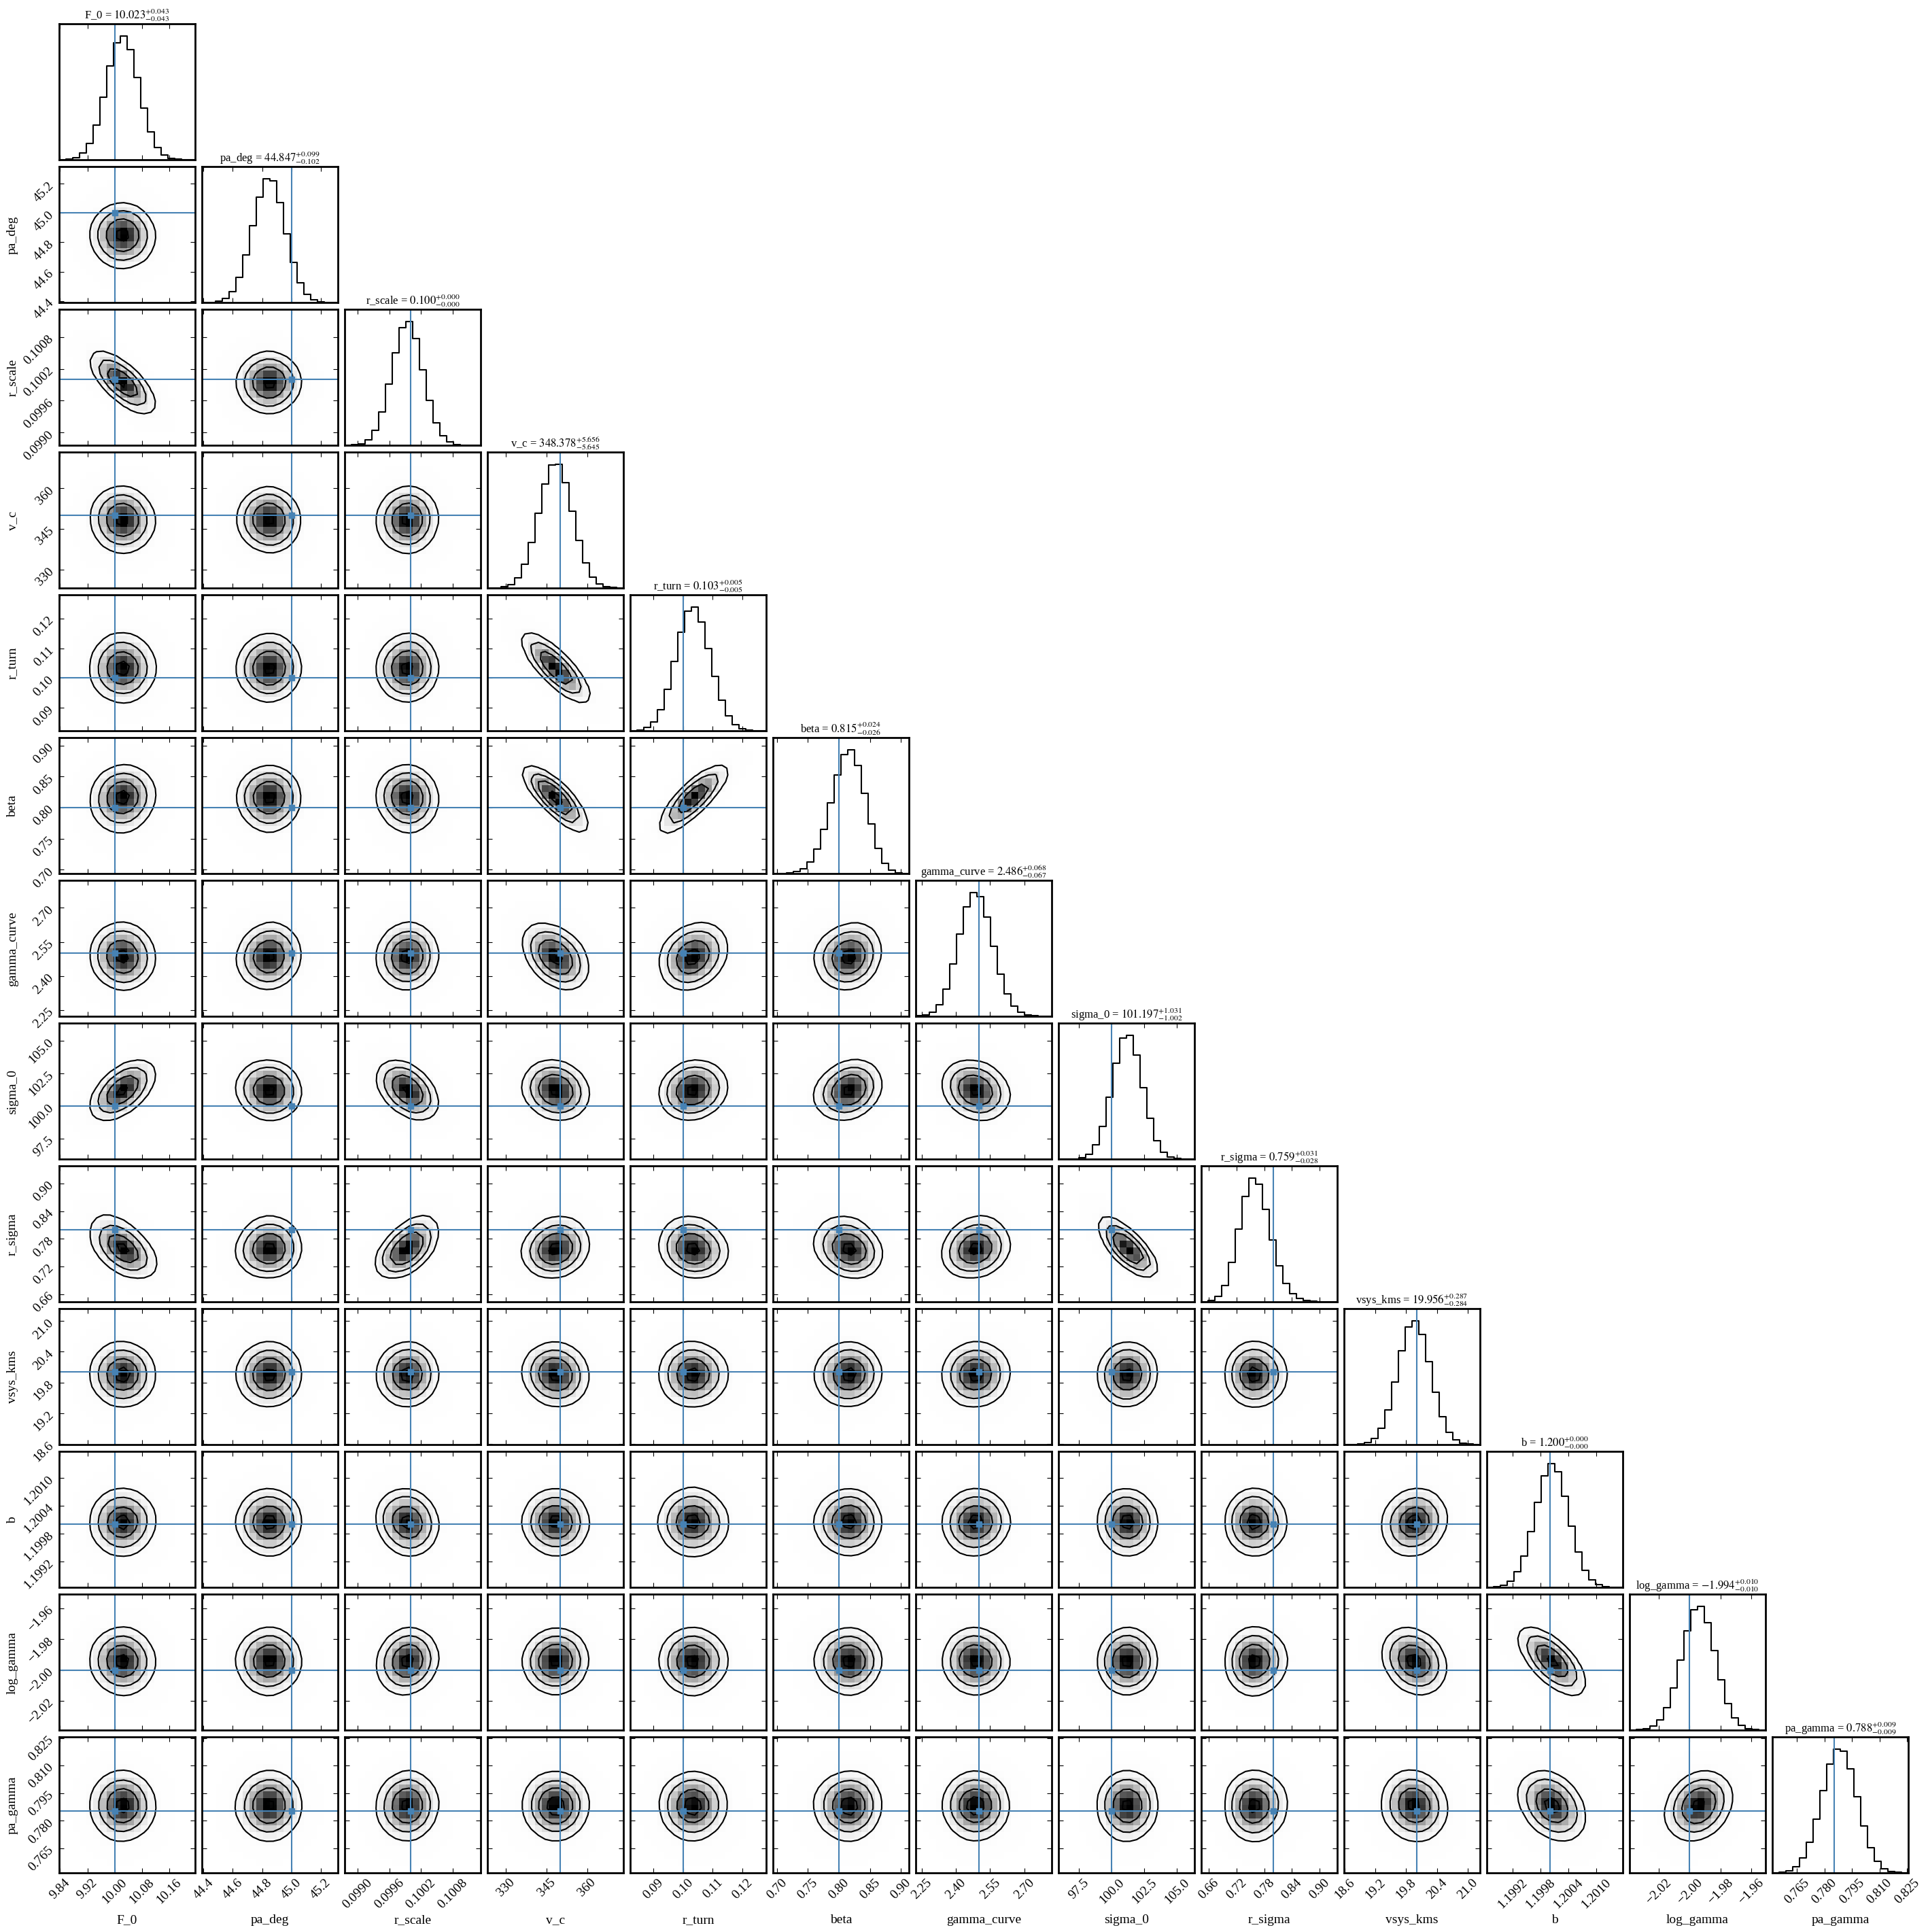


Saved corner plot: ./figure/corner_mock_lens_fix.pdf

 Best-fit parameters vs Truth
F_0           best=   10.0165   truth=   10.0000   Δ=+0.0165
pa_deg        best=   44.8407   truth=   45.0000   Δ=-0.1593
r_scale       best=    0.0999   truth=    0.1000   Δ=-0.0001
v_c           best=  348.7330   truth=  350.0000   Δ=-1.2670
r_turn        best=    0.1029   truth=    0.1000   Δ=+0.0029
beta          best=    0.8114   truth=    0.8000   Δ=+0.0114
gamma_curve   best=    2.4966   truth=    2.5000   Δ=-0.0034
sigma_0       best=  101.3037   truth=  100.0000   Δ=+1.3037
r_sigma       best=    0.7557   truth=    0.8000   Δ=-0.0443
vsys_kms      best=   20.0530   truth=   20.0000   Δ=+0.0530
b             best=    1.2002   truth=    1.2000   Δ=+0.0002
log_gamma     best=   -1.9984   truth=   -2.0000   Δ=+0.0016
pa_gamma      best=    0.7846   truth=    0.7854   Δ=-0.0008

Completed comparison.


In [ ]:
import numpy as np
import corner
import matplotlib.pyplot as plt

# ===============================
# 1. Load saved chain
# ===============================

savename = f"./mcmc_chain_mock_cube_image.npz"
npzfile = np.load(savename, allow_pickle=True)

chain = npzfile["chain"]              # shape: (nsteps, nwalkers, ndim)
logprob = npzfile["logprob"]          # shape: (nsteps, nwalkers)
param_names = list(npzfile["param_names"])

print("Loaded chain:")
print(" chain shape:", chain.shape)
print(" logprob shape:", logprob.shape)
print(" ndim:", len(param_names))


# ===============================
# 2. Truth parameters（mock_params）をここで明示的に入れる
# ===============================

print("\nTruth parameters loaded:")
for name, val in zip(param_names, mock_params):
    print(f" {name:12s} = {val:.4f}")


# ===============================
# 3. Flatten chain
# ===============================

nsteps, nwalkers, ndim = chain.shape
flat_chain = chain.reshape((-1, ndim))

print("\nFlattened chain shape:", flat_chain.shape)


# ===============================
# 4. Corner plot
# ===============================

fig = corner.corner(
    flat_chain,
    labels=param_names,
    truths=mock_params,
    show_titles=True,
    smooth=1.0,
    smooth1d=1.0,
    plot_density=True,
    plot_datapoints=False,
    title_fmt=".3f",
    title_kwargs={"fontsize": 12},
)

fig.savefig("./figure/corner_mock_lens_fix.pdf", dpi=300, bbox_inches="tight", pad_inches=0.05)
plt.show()

print("\nSaved corner plot: ./figure/corner_mock_lens_fix.pdf")

# ===============================
# 5. 真値 vs 最尤推定値
# ===============================

# 最も logprob が大きい点を best-fit とする
idx = np.unravel_index(np.argmax(logprob), logprob.shape)
best_theta = chain[idx[0], idx[1], :]

print("\n==============================")
print(" Best-fit parameters vs Truth")
print("==============================")

for name, best, truth in zip(param_names, best_theta, mock_params):
    print(f"{name:12s}  best={best:10.4f}   truth={truth:10.4f}   Δ={best-truth:+.4f}")

print("\nCompleted comparison.")

In [ ]:
### rotation curve with error band ###
# サンプルから rotation curve を計算
from tqdm import tqdm
from glint.source import Vrot_Courteau1997
n_samples = flat_chain.shape[0]
radius_rc = np.arange(0, 0.8+1e-6, 0.01) # 0含める

# 5個おきのサンプルだけ使う
idx = np.arange(0, n_samples, 5)

vrot_samples = []
for i in tqdm(range(0, n_samples, 5)):
    params = flat_chain[i]
    v_c = params[3]
    r_turn = params[4]
    beta_curve = params[5]
    gamma_curve = params[6]
    vrot_samples.append(Vrot_Courteau1997(r=radius_rc, v_c=v_c, r_turn=r_turn, gamma=gamma_curve, beta=beta_curve))
vrot_samples = np.array(vrot_samples)
vrot_median = np.median(vrot_samples, axis=0)
vrot_16 = np.percentile(vrot_samples, 16, axis=0)
vrot_84 = np.percentile(vrot_samples, 84, axis=0)   

100%|██████████| 104000/104000 [00:01<00:00, 52026.82it/s]


Saved to ./figure/rotation_curve_mock_lens_fix.pdf


<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3608284/1551598634.py:3: SyntaxWarning: invalid escape sequence '\s'
  ax.fill_between(radius_rc, vrot_16, vrot_84, color='blue', alpha=0.3, label='1$\sigma$ uncertainty')


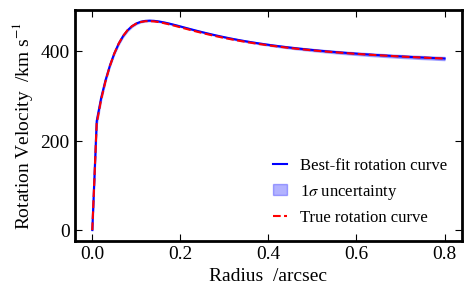

In [ ]:
fig, ax = plt.subplots(figsize=(5,3))
ax.plot(radius_rc, vrot_median, color='blue', label='Best-fit rotation curve')
ax.fill_between(radius_rc, vrot_16, vrot_84, color='blue', alpha=0.3, label='1$\sigma$ uncertainty')
ax.plot(radius_rc, Vrot_Courteau1997(r=radius_rc, v_c=mock_v_c, r_turn=mock_r_turn, gamma=mock_gamma_curve, beta=mock_beta_curve), color='red', linestyle='--', label='True rotation curve')
ax.set_xlabel('Radius  /arcsec', fontsize=14)
ax.set_ylabel(r'Rotation Velocity  /km s$^{-1}$', fontsize=14)
ax.legend(fontsize=12)
# ax.set_ylim(300, 600)
fig.savefig("./figure/rotation_curve_mock_lens_fix.pdf", dpi=200, bbox_inches="tight", pad_inches=0.05)
print("Saved to ./figure/rotation_curve_mock_lens_fix.pdf")
plt.show()

## Compare models and observations

Saved to ./figure/channel_maps_mock_lens_fix.pdf


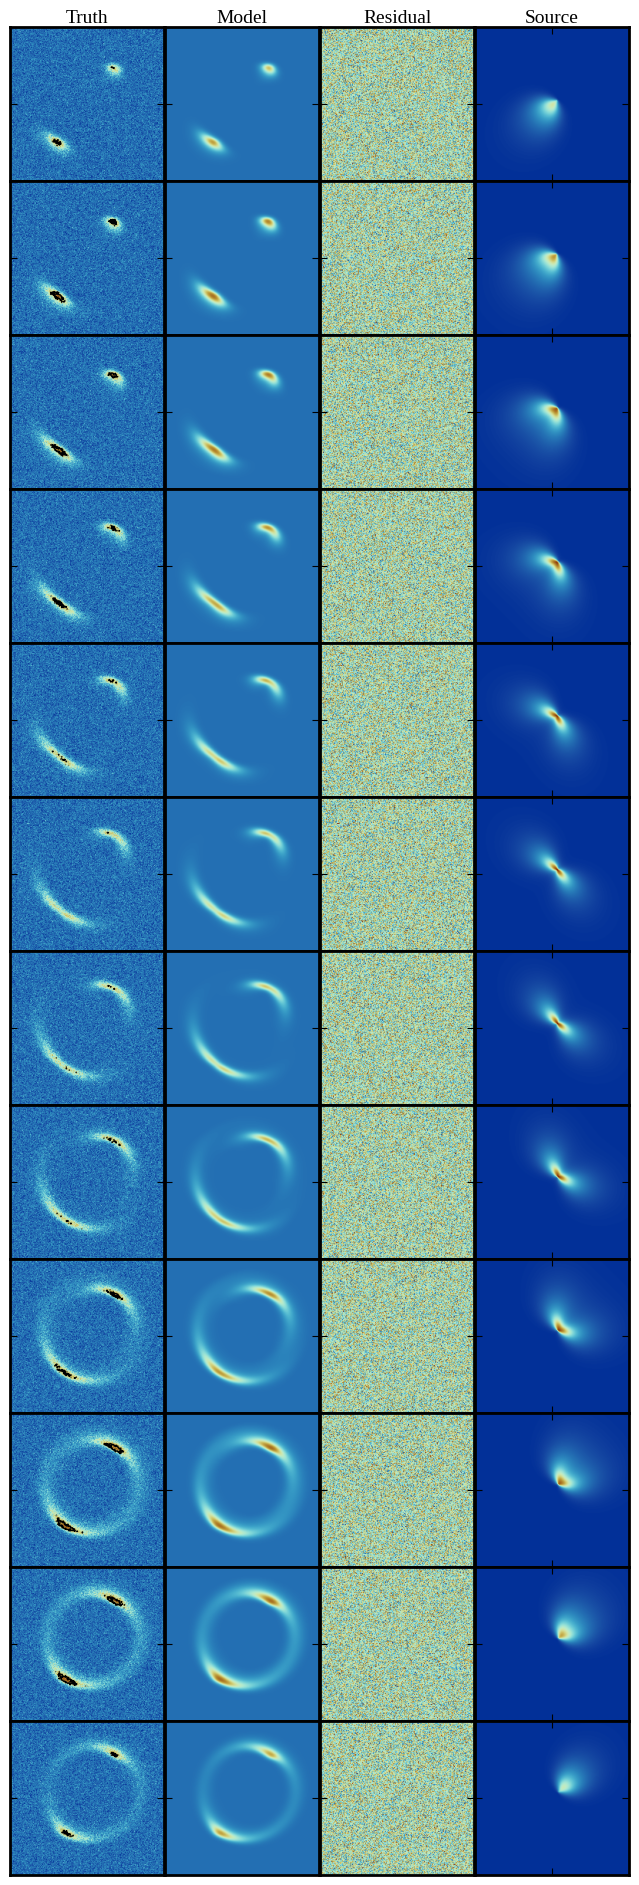

In [ ]:
# model with best-fit parameters
best_source, best_lensed_cube, best_lensed_cube_conv = forward_model_3D_image(best_theta, ctx)

# Plot cube for each channel
# Some settings for plotting
vmax = np.nanmax(mock_lensed_cube_conv)
width = 2
titles = ["Truth", "Model", "Residual", "Source"]


fig, axes = plt.subplots(nchan, ncols=4, figsize=(width*4, width*nchan))
fig.subplots_adjust(wspace=0., hspace=0.0)
for i in range(nchan):
    im0 = axes[i, 0].imshow(mock_lensed_cube_conv[i], cmap=cm.roma_r, origin="lower", vmin=-2*rms, vmax=vmax)
    axes[i, 0].contour(mock_lensed_cube_conv[i]/rms, levels=[8,16,32], colors='black', linewidths=1.0)
    im1 = axes[i, 1].imshow(best_lensed_cube_conv[i], cmap=cm.roma_r, origin="lower", vmin=-2*rms, vmax=vmax)
    im2 = axes[i, 2].imshow((mock_lensed_cube_conv[i] - best_lensed_cube_conv[i]) / rms, cmap=cm.roma_r, origin="lower", vmin=-3, vmax=3)
    im3 = axes[i, 3].imshow(best_source[i], cmap=cm.roma_r, origin="lower", vmin=0, vmax=np.nanmax(best_source))

    if i==0:
        for j in range(4):
            axes[i, j].set_title(titles[j], fontsize=14, pad=-2)
    for j in range(4):
        # divider = make_axes_locatable(axes[i,j])
        # cax = divider.append_axes("right", size="5%", pad=0.)
        # fig.colorbar([im0, im1, im2, im3][j], cax=cax)
        axes[i, j].set_xticklabels([])
        axes[i, j].set_yticklabels([])

    
fig.savefig("./figure/channel_maps_mock_lens_fix.pdf", dpi=200, bbox_inches="tight", pad_inches=0.05)
print("Saved to ./figure/channel_maps_mock_lens_fix.pdf")
# plt.tight_layout()